# HUMAN ACTIVITY RECOGNITION

# Model : SVM & RandomForest

# Load Dataset

In [2]:
import pandas as pd

X_train = pd.read_csv(
    r"C:\Users\anagh\OneDrive\Desktop\DUK\PA\Project1\ucihar-dataset\UCI-HAR Dataset\train\X_train.txt",
    sep='\s+', header=None
)

X_test = pd.read_csv(
    r"C:\Users\anagh\OneDrive\Desktop\DUK\PA\Project1\ucihar-dataset\UCI-HAR Dataset\test\X_test.txt",
    sep='\s+', header=None
)

y_train = pd.read_csv(
    r"C:\Users\anagh\OneDrive\Desktop\DUK\PA\Project1\ucihar-dataset\UCI-HAR Dataset\train\y_train.txt",
    header=None
)

y_test = pd.read_csv(
    r"C:\Users\anagh\OneDrive\Desktop\DUK\PA\Project1\ucihar-dataset\UCI-HAR Dataset\test\y_test.txt",
    header=None
)
print(X_train.shape, X_test.shape)

(7352, 561) (2947, 561)


In [3]:
X_train

,0,1,2,3,4,5,6,7,8,9,...,551,552,553,554,555,556,557,558,559,560
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7347,0.299665,-0.057193,-0.181233,-0.195387,0.039905,0.077078,-0.282301,0.043616,0.060410,0.210795,...,-0.070157,-0.588433,-0.880324,-0.190437,0.829718,0.206972,-0.425619,-0.791883,0.238604,0.049819
7348,0.273853,-0.007749,-0.147468,-0.235309,0.004816,0.059280,-0.322552,-0.029456,0.080585,0.117440,...,0.165259,-0.390738,-0.680744,0.064907,0.875679,-0.879033,0.400219,-0.771840,0.252676,0.050053
7349,0.273387,-0.017011,-0.045022,-0.218218,-0.103822,0.274533,-0.304515,-0.098913,0.332584,0.043999,...,0.195034,0.025145,-0.304029,0.052806,-0.266724,0.864404,0.701169,-0.779133,0.249145,0.040811
7350,0.289654,-0.018843,-0.158281,-0.219139,-0.111412,0.268893,-0.310487,-0.068200,0.319473,0.101702,...,0.013865,0.063907,-0.344314,-0.101360,0.700740,0.936674,-0.589479,-0.785181,0.246432,0.025339


In [4]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7352 entries, 0 to 7351
Columns: 561 entries, 0 to 560
dtypes: float64(561)
memory usage: 31.5 MB


In [5]:
X_train.isnull().sum()

0      0
1      0
2      0
3      0
4      0
      ..
556    0
557    0
558    0
559    0
560    0
Length: 561, dtype: int64

# Label encoding

In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(y_train.values.ravel())
y_test  = le.transform(y_test.values.ravel())

# Model Training

# SVM

In [32]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report,accuracy_score
import joblib

svm = SVC(kernel='rbf')
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print("SVM Results")
print(classification_report(y_test, y_pred_svm))
print("SVM Accuracy:", svm_accuracy)
joblib.dump(svm, "svm_model.pkl")

SVM Results
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       496
           1       0.93      0.96      0.94       471
           2       0.99      0.91      0.95       420
           3       0.94      0.89      0.91       491
           4       0.91      0.95      0.93       532
           5       1.00      1.00      1.00       537

    accuracy                           0.95      2947
   macro avg       0.95      0.95      0.95      2947
weighted avg       0.95      0.95      0.95      2947

SVM Accuracy: 0.9504580929759077


['svm_model.pkl']

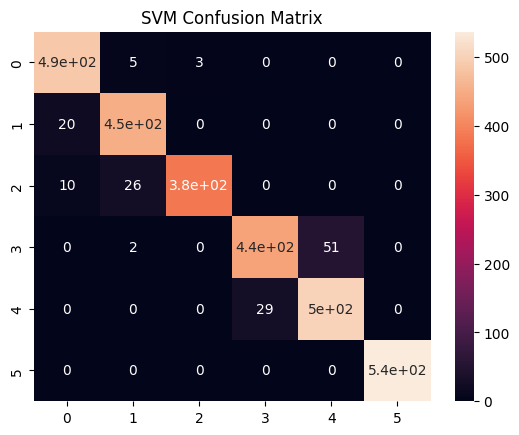

In [29]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_svm)

sns.heatmap(cm, annot=True)
plt.title("SVM Confusion Matrix")
plt.savefig("confusion_matrix_svm.png")

In [20]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred_svm)

with open("svm_report.txt", "w") as f:
    f.write("SVM Results\n")
    f.write(report)

# Random Forest

In [33]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest Results")
print(classification_report(y_test, y_pred_rf))
print("Random Forest Accuracy:", rf_accuracy)
joblib.dump(rf, "rf_model.pkl")

Random Forest Results
              precision    recall  f1-score   support

           0       0.90      0.97      0.93       496
           1       0.90      0.92      0.91       471
           2       0.96      0.86      0.91       420
           3       0.92      0.89      0.90       491
           4       0.90      0.93      0.91       532
           5       1.00      1.00      1.00       537

    accuracy                           0.93      2947
   macro avg       0.93      0.93      0.93      2947
weighted avg       0.93      0.93      0.93      2947

Random Forest Accuracy: 0.9297590770274856


['rf_model.pkl']

In [21]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred_rf)

with open("rf_report.txt", "w") as f:
    f.write("Random Forest Results\n")
    f.write(report)

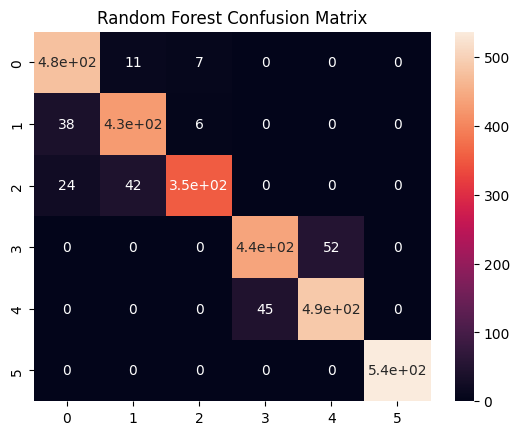

In [28]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True)
plt.title("Random Forest Confusion Matrix")
plt.savefig("confusion_matrix_rf.png")

In [9]:
from sklearn.metrics import accuracy_score

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))

SVM Accuracy: 0.9504580929759077
RF Accuracy: 0.9256871394638616


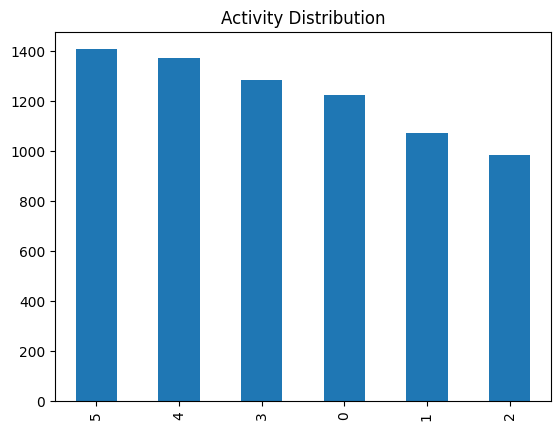

In [10]:
import matplotlib.pyplot as plt

pd.Series(y_train).value_counts().plot(kind='bar')
plt.title("Activity Distribution")
plt.show()

# Comparison of Models

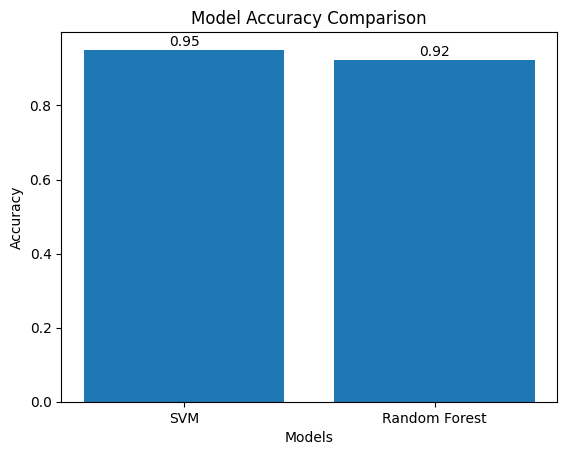

In [16]:
import matplotlib.pyplot as plt

models = ['SVM', 'Random Forest']
accuracies = [svm_accuracy, rf_accuracy]

plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()